In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.datasets import fetch_openml

 ## 1. Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the KNeighborsClassifier works quite well for this task;you just need to find good hyperparameter values (try a grid search on the weights and n_neighbors hyperparameters).

In [2]:
mnist=fetch_openml('mnist_784',parser='auto',as_frame=False)

In [3]:
dir(mnist)

['DESCR',
 'categories',
 'data',
 'details',
 'feature_names',
 'frame',
 'target',
 'target_names',
 'url']

In [4]:
X=mnist.data

In [5]:
y=mnist.target

In [6]:
y=y.astype(np.int8)

In [8]:
def plot_image(an_image):
    an_image=an_image.reshape(28,28)
    plt.imshow(an_image,mpl.cm.binary)
    plt.axis('off')

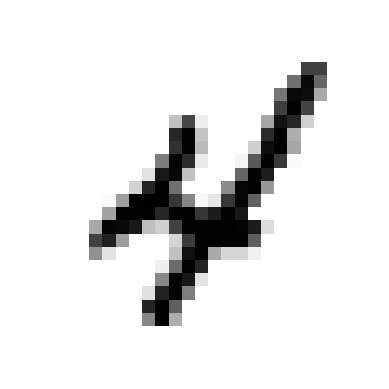

In [9]:
plot_image(X[9])

In [11]:
from sklearn.model_selection import train_test_split

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [53]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [54]:
knn_pred=knn.predict(X_train)

In [48]:
from sklearn.metrics import accuracy_score

In [55]:
accuracy_score(y_train,knn_pred)

0.9808392857142857

In [56]:
accuracy_score(y_test,knn.predict(X_test))

0.9700714285714286

# Hyptermarameter Tuning.

In [60]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid=[
    {'weights':['uniform','distance'],
     'n_neighbors':[3,4,5]
    }
]

In [63]:
clf=KNeighborsClassifier()
grid_search=GridSearchCV(clf,param_grid,cv=3,verbose=3)
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ....n_neighbors=3, weights=uniform;, score=0.968 total time=  42.3s
[CV 2/3] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  41.5s
[CV 3/3] END ....n_neighbors=3, weights=uniform;, score=0.968 total time=  41.5s
[CV 1/3] END ...n_neighbors=3, weights=distance;, score=0.969 total time=  40.1s
[CV 2/3] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  38.9s
[CV 3/3] END ...n_neighbors=3, weights=distance;, score=0.969 total time=  39.6s
[CV 1/3] END ....n_neighbors=4, weights=uniform;, score=0.966 total time=  51.3s
[CV 2/3] END ....n_neighbors=4, weights=uniform;, score=0.969 total time=  51.4s
[CV 3/3] END ....n_neighbors=4, weights=uniform;, score=0.965 total time=  50.9s
[CV 1/3] END ...n_neighbors=4, weights=distance;, score=0.970 total time=  47.9s
[CV 2/3] END ...n_neighbors=4, weights=distance;, score=0.972 total time=  49.6s
[CV 3/3] END ...n_neighbors=4, weights=distance;,

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5],
                          'weights': ['uniform', 'distance']}],
             verbose=3)

In [64]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [65]:
optimized_clf=KNeighborsClassifier(n_neighbors=4,weights='distance')

In [66]:
optimized_clf.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [68]:
y_pred=optimized_clf.predict(X_train)


KeyboardInterrupt: 

In [ ]:
accuracy=accuracy_score(y_train-y_pred)

#### 2. Write a function that can shift an MNIST image in any direction (left, right, up,or down) by one pixel.5 Then, for each image in the training set, create four shif‐ted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set.You should observe that your model performs even better now! This technique of artificially growing the training set is called data augmentation or training set expansion.
- ! Hint: You can use the shift() function from the scipy.ndimage.interpolation module. For example,
shift(image, [2, 1], cval=0) shifts the image 2 pixels down and 1 pixel to the right

In [14]:
from scipy.ndimage.interpolation import shift

C:\Users\jrgau\AppData\Local\Temp\ipykernel_6080\987197595.py:1: DeprecationWarning: Please use `shift` from the `scipy.ndimage` namespace, the `scipy.ndimage.interpolation` namespace is deprecated.
  from scipy.ndimage.interpolation import shift


In [38]:
def shift_image(image,dx,dy):
    image=image.reshape(28,28)
    shifted_image=shift(image,[dy,dx],cval=0,mode='constant')
#     print(shifted_image)
    return shifted_image.reshape([-1])

In [39]:
image=X_train[100]
shifted_down=shift_image(image,0,5)
shifted_left=shift_image(image,-5,0)

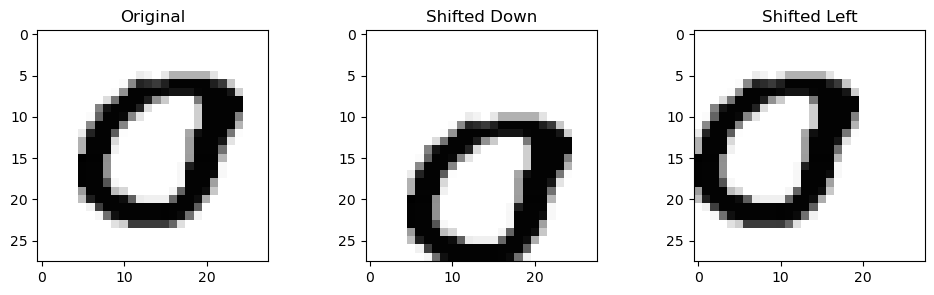

In [49]:
plt.figure(figsize=(12,3))
plt.subplot(131)
plt.title("Original")
plt.imshow(image.reshape(28,28),cmap='Greys',interpolation="nearest")
plt.subplot(132)
plt.title("Shifted Down")
plt.imshow(shifted_down.reshape(28,28),interpolation='nearest',cmap='Greys')
plt.subplot(133)
plt.title("Shifted Left")
plt.imshow(shifted_left.reshape(28,28),interpolation='nearest',cmap='Greys')

In [63]:
y_train

array([5, 4, 8, ..., 1, 0, 0], dtype=int8)

In [66]:
X_train_augmented=[image for image in X_train]
y_train_augmented=[label for label in y_train]

In [76]:
for dx,dy in ((1,0),(-1,0),(0,1),(0,-1)):
    for image,label in zip(X_train,y_train):
        X_train_augmented.append(shift_image(image,dx,dy))
        y_train_augmented.append(label)

In [81]:
X_train_augmented=np.array(X_train_augmented)
y_train_augmented=np.array(y_train_augmented)

In [83]:
shuffle_indx=np.random.permutation(len(X_train_augmented))

In [84]:
X_train_augmented=X_train_augmented[shuffle_indx]
y_train_augmented=y_train_augmented[shuffle_indx]